
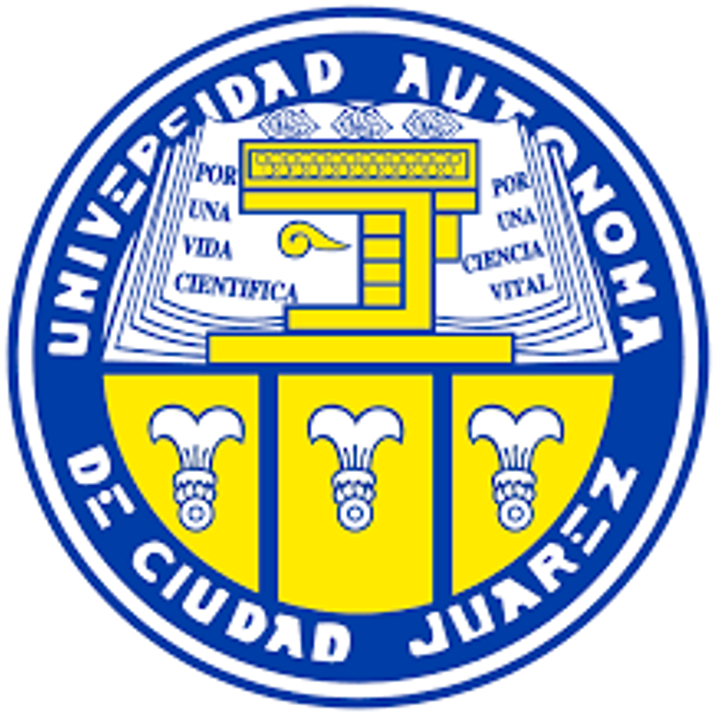

## Tarea 6: Ejercicios: Representación de textos
## Nombre: Sergio Trejo
## Matricula: 261539
## Materia: Procesamiento de Lenguaje Natural_A_Presencial_260206

Considera el pequeño corpus de reseñas de películas y comentarios de redes sociales que está al final del documento y realiza los siguientes ejercicios:

## Ejercicio 1: Utiliza el texto crudo (sin procesar)
*	Crear un CountVectorizer y un TfidfVectorizer.
*	Aplícalos al corpus y transformar los textos.
*	Mostrar:
  *	Dimensiones de la matriz resultante.
  *	Primeros 10 tokens y sus índices.
*	Comparar las diferencias entre ambas matrices (CountVectorizer y TfidfVectorizer), mencionando de manera general las diferencias observadas.


## Ejercicio 2: Preprocesa el texto eliminando los acentos y stopwords, así como convirtiéndolo a minúsculas.
*	Realiza las mismas actividades que en el ejercicio anterior.
*	Compara las matrices del ejercicio anterior con las matrices que obtuviste en este ejercicio, mencionando de manera general las diferencias observadas.

Entregables:
*	Códigos realizados (pueden ser los scripts de Python que desees).
*	Documento PDF con las salidas de los códigos y la comparación de las matrices de cada ejercicio.



In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
import re
import unicodedata

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sergioai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/sergioai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/sergioai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


##Corpus

## Este es un header de prueba

In [10]:
corpus_es =[
    "Me encantó la película, los actores fueron increíbles",
    "No me gustó la película, el guion fue muy malo",
    "La actuación fue excelente, pero la historia era predecible",
    "Película aburrida, me dormí a la mitad",
    "¡Maravillosa! Recomiendo esta película a todos mis amigos",
    "El guion estaba mal escrito, pero la actuación salvó la película",
    "Demasiado larga y lenta, no la volvería a ver",
    "Me gustó mucho, los efectos especiales fueron impresionantes",
    "No es mala, pero esperaba algo más emocionante",
    "Una obra maestra del cine español, increíble dirección",
    "El final fue confuso, no entendí nada",
    "Excelente cinematografía, pero el guion flojo",
    "Demasiado predecible, ya sabía lo que iba a pasar",
    "Me reí mucho, muy divertida y entretenida",
    "La música fue espectacular, pero los actores no convencieron",
    "Película mediocre, no aporta nada nuevo",
    "Excelente historia, emocionante hasta el final",
    "No me gustó la ambientación, parecía de bajo presupuesto",
    "Muy buena dirección y fotografía, la recomiendo",
    "El guion tenía agujeros, pero los efectos visuales impresionan",
    "Aburrida, diálogo poco natural",
    "Gran actuación de los protagonistas, realmente me impactó",
    "El ritmo es lento, pero la historia es interesante",
    "No la recomiendo, desperdicié mi tiempo",
    "Un clásico moderno, me encantó cada escena",
    "Las escenas de acción fueron espectaculares",
    "El humor es pobre y los personajes poco creíbles",
    "Me emocioné, la historia me llegó al corazón",
    "La trama es confusa y difícil de seguir",
    "Película fantástica, muy bien lograda"
]

In [11]:
# Ejercicio 1:

# Crear un CountVectorizer(BoW)
vectorizer = CountVectorizer(lowercase=True, strip_accents='unicode')
X = vectorizer.fit_transform(corpus_es)

#Convertir a Dataframe
bow_df = pd.DataFrame(X.toarray(),
                  columns=vectorizer.get_feature_names_out())

print("Dimensiones de la matriz BoW:", X.shape)

#Mostar los primeros 10 token
print("Primeros 10 tokens e indices:")
for i, token in enumerate(vectorizer.get_feature_names_out()[:10]):
    print(i, "->", token)

print("Primeras filas de la matriz BoW: \n", bow_df.head())

print("-------------------------------------------------------------")

#Crear un TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(lowercase=True, strip_accents='unicode')
X_tfidf = vectorizer_tfidf.fit_transform(corpus_es)

#Convertir a Dataframe
tfidf_df = pd.DataFrame(X_tfidf.toarray(),
                  columns=vectorizer_tfidf.get_feature_names_out())

print("Dimensiones de la matriz tf-idf:", X_tfidf.shape)

# Mostrar los primeros 10 token
print("Primeros 10 tokens e indices: ")
for i, token in enumerate(vectorizer_tfidf.get_feature_names_out()[:10]):
    print(i, "->", token)

print("Primeras filas de la matriz tf-idf: \n", tfidf_df.head())




Dimensiones de la matriz BoW: (30, 127)
Primeros 10 tokens e indices:
0 -> aburrida
1 -> accion
2 -> actores
3 -> actuacion
4 -> agujeros
5 -> al
6 -> algo
7 -> ambientacion
8 -> amigos
9 -> aporta
Primeras filas de la matriz BoW: 
    aburrida  accion  actores  actuacion  agujeros  al  algo  ambientacion  \
0         0       0        1          0         0   0     0             0   
1         0       0        0          0         0   0     0             0   
2         0       0        0          1         0   0     0             0   
3         1       0        0          0         0   0     0             0   
4         0       0        0          0         0   0     0             0   

   amigos  aporta  ...  tenia  tiempo  todos  trama  un  una  ver  visuales  \
0       0       0  ...      0       0      0      0   0    0    0         0   
1       0       0  ...      0       0      0      0   0    0    0         0   
2       0       0  ...      0       0      0      0   0    0    0  

**Conclusion**

* Con CountVectorizer el texto fue convertido en numeros usando el modelo bag of words donde cada reseña en el corpus se transforma en un vector numerico. Con TfidVectorizer tambien se transforma el texto en numeros, pero considerando la importancia de cada palabra.  

* Las matrices resultantes tiene 30 filas(una por cada reseña) y 127 columnas que representan una palabra unica del corpus. La diferencia principal no esta en las palabras, sino en los valores numericos de la matriz.

* La diferencia principal es que BoW muestra frecuencias enteras (cuantas veces aparece una palabra), mientras que TF-IDF genera valores decimales que reducen el peso de palabras muy comunes y resaltan palabras mas relevantes en cada documento.

In [12]:
#Ejercicio 2:

stop_words = set(stopwords.words('spanish'))

corpus_es_limpio = []

for reseña in corpus_es:
  #Convertir a minusculas
  reseña = reseña.lower()
  #Eliminar acentos
  reseña = unicodedata.normalize('NFKD', reseña).encode('ASCII', 'ignore').decode('utf-8')
  #Tokenizar para dividir el texto en palabras individuales
  reseña = word_tokenize(reseña, language='spanish')
  #Eliminar stopwords y signos
  tokens_filtrados = [
      palabra for palabra in reseña
      if palabra not in stop_words and palabra.isalpha()
  ]

  texto_limpio = ' '.join(tokens_filtrados)
  corpus_es_limpio.append(texto_limpio)

print("Primeras reseñas procesadas:")
for reseña in corpus_es_limpio[:5]:
  print(reseña)


print("------------------------------------------------------------")
# Realizar las mismas actividades que en el ejercicio anterior.

# Crear un CountVectorizer(BoW)
vectorizer = CountVectorizer(lowercase=True, strip_accents='unicode')
X = vectorizer.fit_transform(corpus_es_limpio)

#Convertir a Dataframe
bow_df = pd.DataFrame(X.toarray(),
                  columns=vectorizer.get_feature_names_out())

print("Dimensiones de la matriz BoW:", X.shape)

#Mostar los primeros 10 token
print("Primeros 10 tokens e indices:")
for i, token in enumerate(vectorizer.get_feature_names_out()[:10]):
    print(i, "->", token)

print("Primeras filas de la matriz BoW: \n", bow_df.head())


print("-------------------------------------------------------------")

#Crear un TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(lowercase=True, strip_accents='unicode')
X_tfidf = vectorizer_tfidf.fit_transform(corpus_es_limpio)

#Convertir a Dataframe
tfidf_df = pd.DataFrame(X_tfidf.toarray(),
                  columns=vectorizer_tfidf.get_feature_names_out())

print("Dimensiones de la matriz tf-idf:", X_tfidf.shape)

# Mostrar los primeros 10 token
print("Primeros 10 tokens e indices: ")
for i, token in enumerate(vectorizer_tfidf.get_feature_names_out()[:10]):
    print(i, "->", token)

print("Primeras filas de la matriz tf-idf: \n", tfidf_df.head())


Primeras reseñas procesadas:
encanto pelicula actores increibles
gusto pelicula guion malo
actuacion excelente historia predecible
pelicula aburrida dormi mitad
maravillosa recomiendo pelicula amigos
------------------------------------------------------------
Dimensiones de la matriz BoW: (30, 97)
Primeros 10 tokens e indices:
0 -> aburrida
1 -> accion
2 -> actores
3 -> actuacion
4 -> agujeros
5 -> ambientacion
6 -> amigos
7 -> aporta
8 -> bajo
9 -> bien
Primeras filas de la matriz BoW: 
    aburrida  accion  actores  actuacion  agujeros  ambientacion  amigos  \
0         0       0        1          0         0             0       0   
1         0       0        0          0         0             0       0   
2         0       0        0          1         0             0       0   
3         1       0        0          0         0             0       0   
4         0       0        0          0         0             0       1   

   aporta  bajo  bien  ...  ritmo  sabia  salvo  segui

**Conclusion**
* En el ejercicio 1 se utilizaron todas las palabras del corpus original, incluyendo palabrar que son comunes o stopwords y acentos. Esto redujo el numero de terminos del vocabularion en el texto.

* Como resultado, la matriz del ejercicio 2 tiene menor dimensionalidad, ya que solo conserva palabras con mayor valor informativo en el contexto, reduciendo el ruido en la representacion final del texto.

* Aunque las dimensiones cambian entre ambos ejercicios, la diferencia entre BoW y TF-IDF se mantiene similar. BoW muestra frecuencias enteras (cuantas veces aparece una palabra), mientras que TF-IDF genera pesos que reflejan la importancia relativa de cada palabra dentro del conjunto de documentos.